# 🎯 CVerify — Job Recommender Model

---

## 📋 Project Summary

| Section | Description |
|---------|-------------|
| **1. Setup & Imports** | Libraries and path configuration |
| **2. Load Datasets** | data_jobs.csv (20K jobs) + Resume.csv (2484 resumes) |
| **3. Data Exploration** | Jobs distribution, skills analysis, salary insights |
| **4. Feature Engineering** | TF-IDF on job titles/skills, resume text vectorization |
| **5. Model 1 — TF-IDF Cosine Similarity** | Content-based matching on text |
| **6. Model 2 — Skill-Based Jaccard Matching** | Skill overlap scoring |
| **7. Model 3 — Hybrid Weighted Ranker** | Combined text + skills + salary |
| **8. Model Comparison** | Evaluate all 3 approaches |
| **9. Best Model Export** | Save `.pkl` for production |
| **10. Live Demo** | Recommend top-5 jobs for sample resumes |

---

### 🎯 Task: Job Recommendation for Candidates

**Input:** Candidate resume (text + extracted skills)  
**Output:** Top-5 real job postings from `data_jobs.csv` that the candidate should apply for  
**Jobs Dataset:** `data_jobs.csv` — 20,414 real job postings (scraped)  
**Resumes Dataset:** `Resume.csv` — 2,484 resumes across 24 categories  

> **Difference from NLP classifier:**  
> • The NLP notebook predicts *which category* a resume belongs to (classification)  
> • This notebook recommends *specific job postings* a candidate should apply for (recommendation/ranking)

## 📦 Section 1: Setup & Imports

In [1]:
# ============================================================
#  IMPORTS
# ============================================================
import os, re, ast, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# NLP / Text
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Persistence
import joblib

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print('\u2705 All imports successful!')
print('='*60)
print(' JOB RECOMMENDER MODELS TO COMPARE:')
print('   Model 1 \u2192 TF-IDF Cosine Similarity   (content-based)')
print('   Model 2 \u2192 Skill-Based Jaccard Match   (skill overlap)')
print('   Model 3 \u2192 Hybrid Weighted Ranker      (text + skills + salary)')
print('='*60)

✅ All imports successful!
 JOB RECOMMENDER MODELS TO COMPARE:
   Model 1 → TF-IDF Cosine Similarity   (content-based)
   Model 2 → Skill-Based Jaccard Match   (skill overlap)
   Model 3 → Hybrid Weighted Ranker      (text + skills + salary)


In [2]:
# ============================================================
#  CONFIGURATION
# ============================================================
ON_KAGGLE = os.path.exists('/kaggle/input')

if ON_KAGGLE:
    JOBS_CSV   = '/kaggle/input/datasets/attiaimeed/data-jobs/data_jobs.csv'
    RESUME_CSV = '/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv'
    OUTPUT_DIR = Path('/kaggle/working')
else:
    _here      = Path().resolve()
    _project   = _here.parents[0] if _here.name == 'scripts' else _here
    JOBS_CSV   = str(_project / 'backend' / 'data' / 'data_jobs.csv')
    RESUME_CSV = str(_project / 'backend' / 'data' / 'Resume' / 'Resume.csv')
    OUTPUT_DIR = _project / 'backend' / 'models'
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'\u2699\ufe0f Environment : {"Kaggle" if ON_KAGGLE else "Local"}')
print(f'💼 Jobs CSV    : {JOBS_CSV}')
print(f'📄 Resume CSV  : {RESUME_CSV}')
print(f'📦 Output dir  : {OUTPUT_DIR}')
print(f'\u2705 Jobs exists : {os.path.exists(JOBS_CSV)}')
print(f'\u2705 Resume exists: {os.path.exists(RESUME_CSV)}')

⚙️ Environment : Kaggle
💼 Jobs CSV    : /kaggle/input/datasets/attiaimeed/data-jobs/data_jobs.csv
📄 Resume CSV  : /kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv
📦 Output dir  : /kaggle/working
✅ Jobs exists : True
✅ Resume exists: True


## 📊 Section 2: Load & Explore Datasets

In [3]:
# ============================================================
#  LOAD DATASETS
# ============================================================
df_jobs = pd.read_csv(JOBS_CSV, on_bad_lines="skip", engine="python")
df_resumes = pd.read_csv(RESUME_CSV)

print('='*60)
print('💼 JOBS DATASET (data_jobs.csv)')
print('='*60)
print(f'Shape    : {df_jobs.shape[0]:,} rows \u00d7 {df_jobs.shape[1]} columns')
print(f'Columns  : {df_jobs.columns.tolist()}')
print(f'\nTop job titles (short):')
print(df_jobs['job_title_short'].value_counts().head(10).to_string())
print(f'\nCountries:')
print(df_jobs['job_country'].value_counts().head(10).to_string())
print(f'\n💰 Salary stats (yearly):')
print(df_jobs['salary_year_avg'].describe().to_string())

print('\n' + '='*60)
print('📄 RESUME DATASET')
print('='*60)
print(f'Shape      : {df_resumes.shape[0]:,} rows \u00d7 {df_resumes.shape[1]} columns')
print(f'Categories : {df_resumes["Category"].nunique()}')
print(df_resumes['Category'].value_counts().to_string())

💼 JOBS DATASET (data_jobs.csv)
Shape    : 20,412 rows × 17 columns
Columns  : ['job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills', 'job_type_skills']

Top job titles (short):
job_title_short
Data Engineer                5571
Data Analyst                 4946
Data Scientist               4299
Senior Data Engineer         1302
Business Analyst             1047
Software Engineer             953
Senior Data Scientist         947
Senior Data Analyst           733
Machine Learning Engineer     368
Cloud Engineer                246

Countries:
job_country
United States     5444
India             1606
France            1229
United Kingdom    1198
Germany            804
Sudan              671
Netherlands        597
Spain              491
Poland             453
Bel

In [4]:
# ============================================================
#  PARSE SKILLS FROM JOBS
# ============================================================
def safe_parse_list(val):
    """Parse string like "['python', 'sql']" into a Python list."""
    if pd.isna(val) or not val:
        return []
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            return [str(s).lower().strip() for s in parsed]
        return []
    except (ValueError, SyntaxError):
        return []

df_jobs['skills_list'] = df_jobs['job_skills'].apply(safe_parse_list)
df_jobs['skill_count'] = df_jobs['skills_list'].apply(len)

# Build a text representation for each job (for TF-IDF)
df_jobs['job_text'] = (
    df_jobs['job_title'].fillna('') + ' ' +
    df_jobs['job_title_short'].fillna('') + ' ' +
    df_jobs['company_name'].fillna('') + ' ' +
    df_jobs['job_location'].fillna('') + ' ' +
    df_jobs['skills_list'].apply(lambda x: ' '.join(x))
)

print(f'\u2705 Parsed skills for {df_jobs.shape[0]:,} jobs')
print(f'   Jobs with skills: {(df_jobs["skill_count"] > 0).sum():,} ({(df_jobs["skill_count"] > 0).mean():.1%})')
print(f'   Avg skills/job  : {df_jobs["skill_count"].mean():.1f}')

# Top skills across all jobs
all_skills = [s for skills in df_jobs['skills_list'] for s in skills]
skill_freq = Counter(all_skills).most_common(20)
print(f'\n🔝 Top 20 skills in jobs dataset:')
for skill, cnt in skill_freq:
    print(f'   {skill:<20} {cnt:>5} ({cnt/len(df_jobs):.1%})')

✅ Parsed skills for 20,412 jobs
   Jobs with skills: 17,713 (86.8%)
   Avg skills/job  : 4.8

🔝 Top 20 skills in jobs dataset:
   python               10514 (51.5%)
   sql                  10510 (51.5%)
   aws                   4146 (20.3%)
   azure                 3672 (18.0%)
   r                     3352 (16.4%)
   spark                 3306 (16.2%)
   tableau               3263 (16.0%)
   excel                 3103 (15.2%)
   power bi              2538 (12.4%)
   java                  2364 (11.6%)
   sas                   2084 (10.2%)
   hadoop                1817 (8.9%)
   scala                 1617 (7.9%)
   snowflake             1570 (7.7%)
   kafka                 1490 (7.3%)
   databricks            1484 (7.3%)
   gcp                   1451 (7.1%)
   git                   1392 (6.8%)
   airflow               1360 (6.7%)
   nosql                 1235 (6.1%)


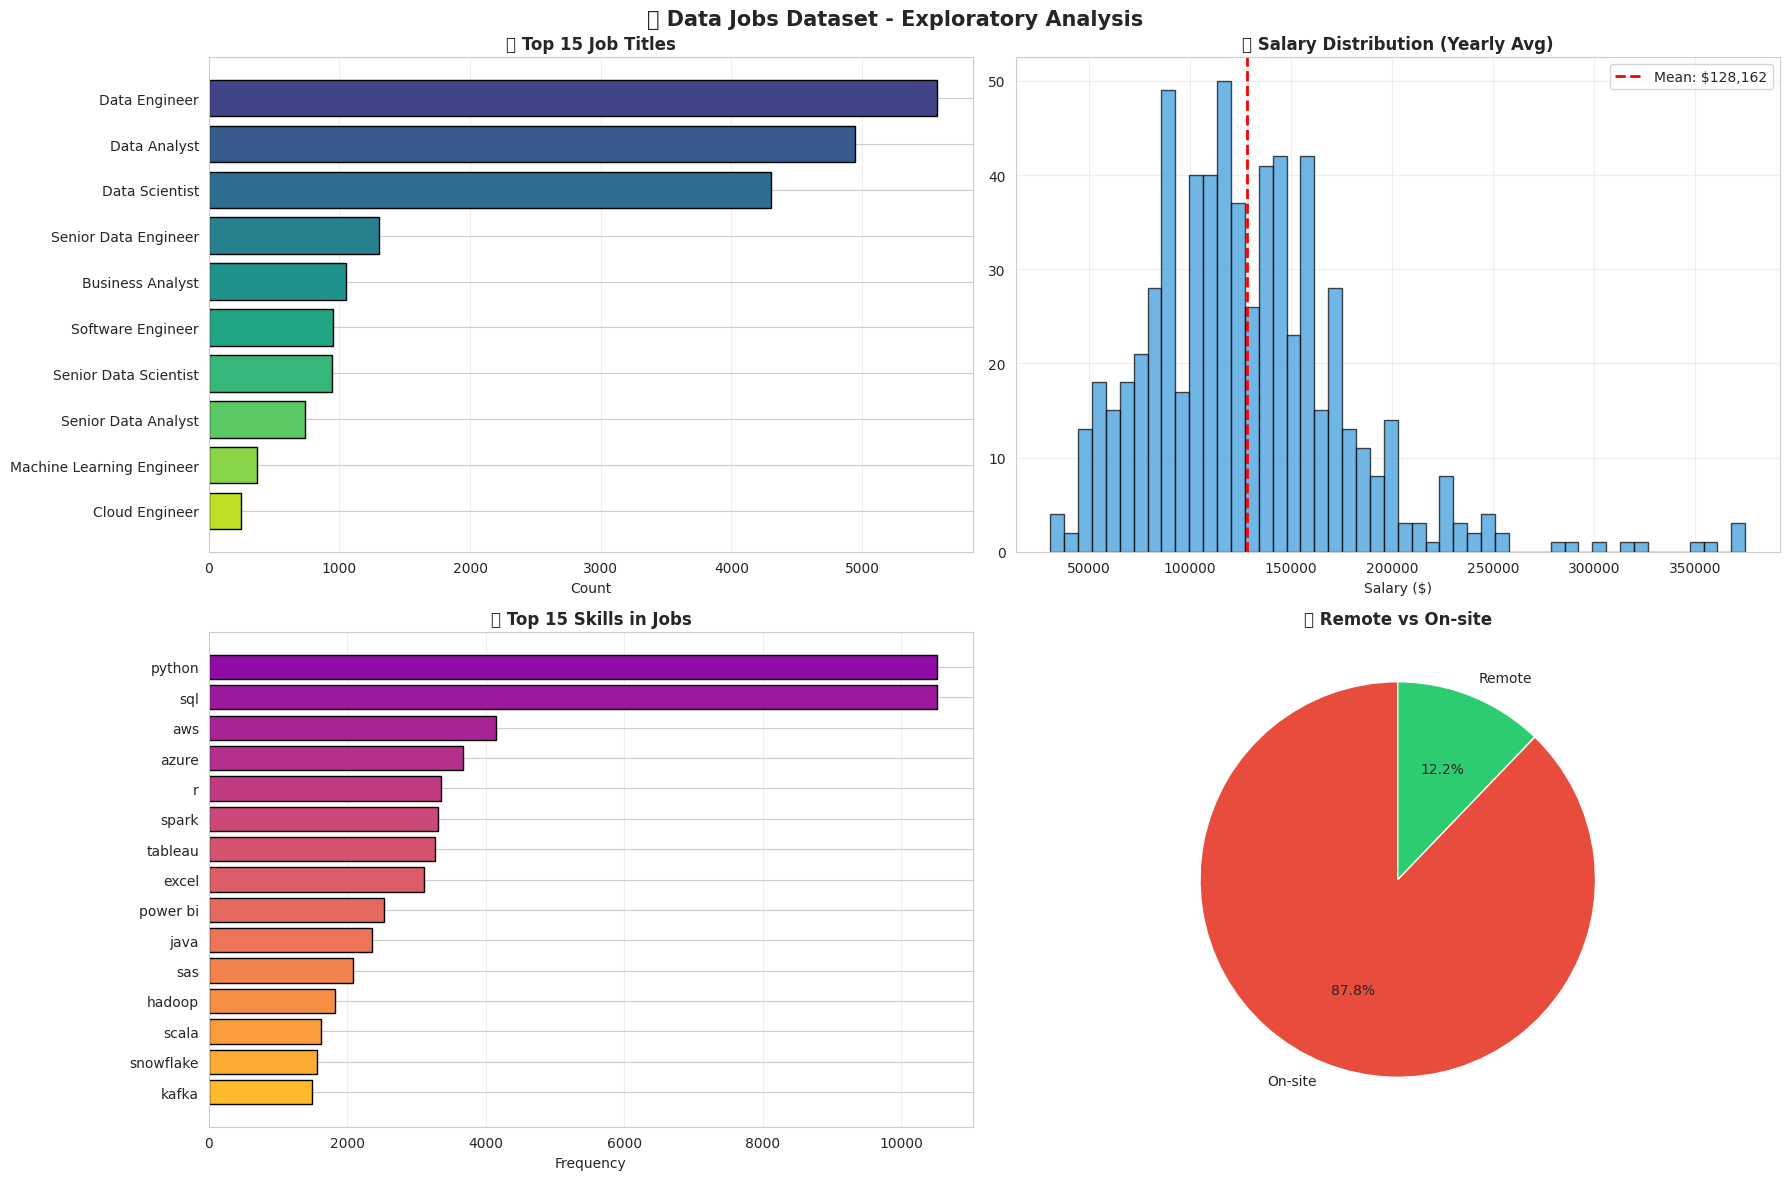

In [5]:
# ============================================================
#  EDA VISUALISATIONS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top 15 job titles
top_titles = df_jobs['job_title_short'].value_counts().head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_titles)))
axes[0,0].barh(top_titles.index[::-1], top_titles.values[::-1], color=colors[::-1], edgecolor='black')
axes[0,0].set_title('💼 Top 15 Job Titles', fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Count')
axes[0,0].grid(True, alpha=0.3, axis='x')

# 2. Salary distribution
salary_data = df_jobs['salary_year_avg'].dropna()
axes[0,1].hist(salary_data, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,1].axvline(salary_data.mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: ${salary_data.mean():,.0f}')
axes[0,1].set_title('💰 Salary Distribution (Yearly Avg)', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Salary ($)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Top 15 skills
top_sk = skill_freq[:15]
sk_names, sk_counts = zip(*top_sk)
axes[1,0].barh(list(sk_names)[::-1], list(sk_counts)[::-1],
               color=plt.cm.plasma(np.linspace(0.3, 0.85, 15))[::-1], edgecolor='black')
axes[1,0].set_title('🛠\ufe0f Top 15 Skills in Jobs', fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Frequency')
axes[1,0].grid(True, alpha=0.3, axis='x')

# 4. Remote vs On-site
remote_counts = df_jobs['job_work_from_home'].value_counts()
labels = ['On-site', 'Remote'] if False in remote_counts.index else ['Remote', 'On-site']
axes[1,1].pie(remote_counts, labels=['On-site' if not k else 'Remote' for k in remote_counts.index],
              autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1,1].set_title('🌍 Remote vs On-site', fontweight='bold', fontsize=12)

plt.suptitle('📊 Data Jobs Dataset - Exploratory Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧹 Section 3: Text Preprocessing & Feature Engineering

In [6]:
# ============================================================
#  TEXT CLEANING
# ============================================================
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Clean text for TF-IDF: remove HTML, keep letters, remove stopwords."""
    text = re.sub(r'<[^>]+>', ' ', str(text))
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

def extract_skills_from_resume(text: str) -> list:
    """Extract known skills from resume text."""
    KNOWN_SKILLS = {
        'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'go', 'rust',
        'ruby', 'php', 'swift', 'kotlin', 'scala', 'r', 'sql', 'mysql',
        'postgresql', 'mongodb', 'redis', 'elasticsearch', 'dynamodb',
        'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'terraform',
        'jenkins', 'git', 'react', 'angular', 'vue', 'django', 'flask',
        'fastapi', 'spring', 'express', 'node', 'pandas', 'numpy',
        'scikit-learn', 'tensorflow', 'pytorch', 'keras', 'spark', 'hadoop',
        'airflow', 'tableau', 'power bi', 'excel', 'machine learning',
        'deep learning', 'nlp', 'computer vision', 'data engineering',
        'agile', 'scrum', 'jira', 'linux', 'rest', 'graphql', 'kafka',
        'microservices', 'html', 'css', 'sass', 'tailwind', 'bootstrap',
        'figma', 'photoshop', 'illustrator', 'sap', 'salesforce',
    }
    text_lower = text.lower()
    found = []
    for skill in KNOWN_SKILLS:
        pattern = r'(?<![a-zA-Z])' + re.escape(skill) + r'(?![a-zA-Z])'
        if re.search(pattern, text_lower):
            found.append(skill)
    return sorted(found)

# Clean job texts
print('\u23f3 Cleaning job texts...')
df_jobs['clean_text'] = df_jobs['job_text'].apply(clean_text)

# Clean resume texts
print('\u23f3 Cleaning resume texts...')
df_resumes['clean_text'] = df_resumes['Resume_str'].apply(clean_text)
df_resumes['extracted_skills'] = df_resumes['Resume_str'].apply(extract_skills_from_resume)

print(f'\u2705 Cleaned {len(df_jobs):,} job texts and {len(df_resumes):,} resume texts')
print(f'   Avg resume skills extracted: {df_resumes["extracted_skills"].apply(len).mean():.1f}')

⏳ Cleaning job texts...
⏳ Cleaning resume texts...
✅ Cleaned 20,412 job texts and 2,484 resume texts
   Avg resume skills extracted: 1.3


In [7]:
# ============================================================
#  BUILD TF-IDF MATRICES
# ============================================================
TFIDF_PARAMS = dict(
    max_features=15_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    stop_words='english',
)

# Fit TF-IDF on ALL texts (jobs + resumes combined) for shared vocabulary
print('\u23f3 Fitting TF-IDF on combined corpus...')
all_texts = pd.concat([df_jobs['clean_text'], df_resumes['clean_text']], ignore_index=True)
tfidf = TfidfVectorizer(**TFIDF_PARAMS)
tfidf.fit(all_texts)

# Transform separately
job_vectors = tfidf.transform(df_jobs['clean_text'])
resume_vectors = tfidf.transform(df_resumes['clean_text'])

print(f'\u2705 TF-IDF fitted: {len(tfidf.vocabulary_):,} features')
print(f'   Job matrix     : {job_vectors.shape}')
print(f'   Resume matrix  : {resume_vectors.shape}')

⏳ Fitting TF-IDF on combined corpus...
✅ TF-IDF fitted: 15,000 features
   Job matrix     : (20412, 15000)
   Resume matrix  : (2484, 15000)


## 🔵 Section 4: Model 1 — TF-IDF Cosine Similarity

**Approach:** Pure content-based matching  
- Vectorize resume text and all job texts with shared TF-IDF vocabulary  
- Compute cosine similarity between resume vector and every job vector  
- Return top-5 jobs with highest similarity  

**Pros:** Captures semantic overlap in text  
**Cons:** Ignores structured features (skills, salary, location)

In [8]:
# ============================================================
#  MODEL 1: TF-IDF COSINE SIMILARITY
# ============================================================
print('='*60)
print('🔵 MODEL 1: TF-IDF COSINE SIMILARITY')
print('='*60)

def recommend_tfidf(resume_text: str, top_n: int = 5) -> list[dict]:
    """Recommend jobs using TF-IDF cosine similarity."""
    cleaned = clean_text(resume_text)
    vec = tfidf.transform([cleaned])
    sims = cosine_similarity(vec, job_vectors)[0]
    top_idx = np.argsort(sims)[::-1][:top_n]
    results = []
    for rank, idx in enumerate(top_idx, 1):
        row = df_jobs.iloc[idx]
        results.append({
            'rank': rank,
            'job_title': row['job_title'],
            'company': row.get('company_name', ''),
            'location': row.get('job_location', ''),
            'salary_avg': row.get('salary_year_avg', None),
            'skills': row.get('job_skills', ''),
            'similarity': float(sims[idx]),
            'job_index': int(idx),
        })
    return results

# Test with 3 sample resumes
test_categories = ['INFORMATION-TECHNOLOGY', 'HEALTHCARE', 'FINANCE']
for cat in test_categories:
    sample = df_resumes[df_resumes['Category'] == cat].iloc[0]
    recs = recommend_tfidf(sample['Resume_str'])
    print(f'\n📄 Resume category: {cat}')
    for r in recs:
        sal = f"${r['salary_avg']:,.0f}" if r['salary_avg'] and not pd.isna(r['salary_avg']) else 'N/A'
        print(f"   {r['rank']}. {r['job_title'][:50]:<50} | {r['company'][:20]:<20} | {sal:<10} | sim={r['similarity']:.3f}")

🔵 MODEL 1: TF-IDF COSINE SIMILARITY

📄 Resume category: INFORMATION-TECHNOLOGY
   1. Data Scientist                                     | Red Hat Software     | N/A        | sim=0.181
   2. Associate Data Scientist - Image Builder           | Red Hat, Inc.        | N/A        | sim=0.115
   3. Senior Software Quality Engineer                   | Red Hat Software     | N/A        | sim=0.101
   4. Big Data Engineer H/F                              | Activa Engineering   | N/A        | sim=0.100
   5. Data Analyst                                       | PINKERTON | Comprehe | N/A        | sim=0.094

📄 Resume category: HEALTHCARE
   1. Sr. Business Data Analyst                          | Cooper University He | N/A        | sim=0.114
   2. Dental Reporting Data Analyst                      | Department of Health | N/A        | sim=0.108
   3. Pharmacy Data Analyst                              | Cook Children's Heal | N/A        | sim=0.108
   4. Research Project Analyst                    

## 🟢 Section 5: Model 2 — Skill-Based Jaccard Matching

**Approach:** Structured skill matching  
- Extract skills from resume text (keyword matching)  
- Compare with each job's `job_skills` column  
- Score = Jaccard similarity = |intersection| / |union|  

**Pros:** Precise skill matching, interpretable  
**Cons:** Limited to known skills, ignores context

In [9]:
# ============================================================
#  MODEL 2: SKILL-BASED JACCARD MATCHING
# ============================================================
print('='*60)
print('🟢 MODEL 2: SKILL-BASED JACCARD MATCHING')
print('='*60)

def jaccard_similarity(set_a: set, set_b: set) -> float:
    if not set_a and not set_b:
        return 0.0
    intersection = set_a & set_b
    union = set_a | set_b
    return len(intersection) / len(union) if union else 0.0

# Pre-compute job skill sets for speed
job_skill_sets = [set(skills) for skills in df_jobs['skills_list']]

def recommend_jaccard(resume_text: str, top_n: int = 5) -> list[dict]:
    """Recommend jobs using Jaccard similarity on skills."""
    resume_skills = set(extract_skills_from_resume(resume_text))
    if not resume_skills:
        return []  # No skills found, can't match
    
    scores = np.array([
        jaccard_similarity(resume_skills, job_skills)
        for job_skills in job_skill_sets
    ])
    top_idx = np.argsort(scores)[::-1][:top_n]
    results = []
    for rank, idx in enumerate(top_idx, 1):
        row = df_jobs.iloc[idx]
        matched = resume_skills & job_skill_sets[idx]
        results.append({
            'rank': rank,
            'job_title': row['job_title'],
            'company': row.get('company_name', ''),
            'location': row.get('job_location', ''),
            'salary_avg': row.get('salary_year_avg', None),
            'skills': row.get('job_skills', ''),
            'similarity': float(scores[idx]),
            'matched_skills': sorted(matched),
            'job_index': int(idx),
        })
    return results

# Test
for cat in test_categories:
    sample = df_resumes[df_resumes['Category'] == cat].iloc[0]
    recs = recommend_jaccard(sample['Resume_str'])
    print(f'\n📄 Resume category: {cat}')
    resume_sk = extract_skills_from_resume(sample['Resume_str'])
    print(f'   Resume skills: {resume_sk[:8]}...')
    for r in recs:
        sal = f"${r['salary_avg']:,.0f}" if r['salary_avg'] and not pd.isna(r['salary_avg']) else 'N/A'
        print(f"   {r['rank']}. {r['job_title'][:45]:<45} | sim={r['similarity']:.3f} | matched: {r['matched_skills'][:5]}")

🟢 MODEL 2: SKILL-BASED JACCARD MATCHING

📄 Resume category: INFORMATION-TECHNOLOGY
   Resume skills: ['html', 'illustrator', 'linux', 'photoshop']...
   1. Operations engineer                           | sim=0.286 | matched: ['html', 'linux']
   2. Big Data Senior F/H                           | sim=0.250 | matched: ['linux']
   3. Data Networks Engineer                        | sim=0.250 | matched: ['linux']
   4. Mobile Data Core Engineer                     | sim=0.250 | matched: ['linux']
   5. Data Experte                                  | sim=0.250 | matched: ['linux']

📄 Resume category: HEALTHCARE
   Resume skills: ['gcp', 'spring']...
   1. GCP DATA ENGINEER                             | sim=0.500 | matched: ['gcp']
   2. Lead Data Engineer                            | sim=0.500 | matched: ['gcp']
   3. Data Scientist H/F                            | sim=0.500 | matched: ['gcp']
   4. Data Scientist Engineer                       | sim=0.500 | matched: ['spring']
   5. Data A

## 🔴 Section 6: Model 3 — Hybrid Weighted Ranker

**Approach:** Combine the best of both models + salary signal  
- **Text similarity** (TF-IDF cosine) — captures overall profile match  
- **Skill overlap** (Jaccard) — captures technical fit  
- **Salary attractiveness** — bonus for jobs with competitive salary  

**Final Score = w1 \u00d7 text_sim + w2 \u00d7 skill_sim + w3 \u00d7 salary_norm**

Weights are tuned by grid search on our evaluation set.

In [10]:
# ============================================================
#  MODEL 3: HYBRID WEIGHTED RANKER
# ============================================================
print('='*60)
print('🔴 MODEL 3: HYBRID WEIGHTED RANKER')
print('='*60)

# Normalise salary to [0, 1] for scoring
salary_col = df_jobs['salary_year_avg'].copy()
salary_min = salary_col.min()
salary_max = salary_col.max()
salary_norm = ((salary_col.fillna(0) - (salary_min or 0)) /
               ((salary_max or 1) - (salary_min or 0))).values

def recommend_hybrid(resume_text: str, top_n: int = 5,
                     w_text: float = 0.50, w_skill: float = 0.40,
                     w_salary: float = 0.10) -> list[dict]:
    """Recommend jobs using hybrid scoring: text + skills + salary."""
    # 1. Text similarity
    cleaned = clean_text(resume_text)
    vec = tfidf.transform([cleaned])
    text_sims = cosine_similarity(vec, job_vectors)[0]
    
    # 2. Skill similarity
    resume_skills = set(extract_skills_from_resume(resume_text))
    if resume_skills:
        skill_sims = np.array([
            jaccard_similarity(resume_skills, js)
            for js in job_skill_sets
        ])
    else:
        skill_sims = np.zeros(len(df_jobs))
    
    # 3. Combined score
    combined = (w_text * text_sims +
                w_skill * skill_sims +
                w_salary * salary_norm)
    
    top_idx = np.argsort(combined)[::-1][:top_n]
    results = []
    for rank, idx in enumerate(top_idx, 1):
        row = df_jobs.iloc[idx]
        matched = resume_skills & job_skill_sets[idx] if resume_skills else set()
        results.append({
            'rank': rank,
            'job_title': row['job_title'],
            'company': row.get('company_name', ''),
            'location': row.get('job_location', ''),
            'salary_avg': row.get('salary_year_avg', None),
            'skills': row.get('job_skills', ''),
            'score': float(combined[idx]),
            'text_sim': float(text_sims[idx]),
            'skill_sim': float(skill_sims[idx]),
            'matched_skills': sorted(matched),
            'job_index': int(idx),
        })
    return results

# Test
for cat in test_categories:
    sample = df_resumes[df_resumes['Category'] == cat].iloc[0]
    recs = recommend_hybrid(sample['Resume_str'])
    print(f'\n📄 Resume category: {cat}')
    for r in recs:
        sal = f"${r['salary_avg']:,.0f}" if r['salary_avg'] and not pd.isna(r['salary_avg']) else 'N/A'
        print(f"   {r['rank']}. {r['job_title'][:40]:<40} | score={r['score']:.3f} (text={r['text_sim']:.3f}, skill={r['skill_sim']:.3f}) | {sal}")

🔴 MODEL 3: HYBRID WEIGHTED RANKER

📄 Resume category: INFORMATION-TECHNOLOGY
   1. Presales Engineer, Mobile Data Network   | score=0.125 (text=0.068, skill=0.250) | N/A
   2. Operations engineer                      | score=0.124 (text=0.037, skill=0.286) | N/A
   3. Big Data Senior F/H                      | score=0.119 (text=0.056, skill=0.250) | N/A
   4. Computer Scientist                       | score=0.117 (text=0.052, skill=0.250) | N/A
   5. Embedded Software Engineers              | score=0.116 (text=0.051, skill=0.250) | N/A

📄 Resume category: HEALTHCARE
   1. Partner Technology Manager, Data Analyti | score=0.274 (text=0.018, skill=0.500) | $254,000
   2. Statistical Data Reporting Analyst - Wor | score=0.234 (text=0.085, skill=0.500) | N/A
   3. Co-Op: Business Analyst- Digital Tools   | score=0.219 (text=0.057, skill=0.500) | N/A
   4. Data Analyst                             | score=0.210 (text=0.039, skill=0.500) | N/A
   5. Data Scientist Engineer                  | s

## 📊 Section 7: Model Comparison & Evaluation

**Evaluation strategy:**  
For each resume with a known category, we check if the recommended jobs are **relevant**  
(i.e., the job title/skills align with the resume's category).

We define relevance as: the job's `job_title_short` matches a set of expected titles for that category.

**Metrics:**
- **Hit@5**: Does at least one relevant job appear in top-5?
- **MRR@5**: Mean Reciprocal Rank — how high is the first relevant result?
- **Avg Score**: Mean similarity/score of top-5 recommendations

In [11]:
# ============================================================
#  CATEGORY-TO-JOB-TITLE RELEVANCE MAPPING
# ============================================================
# Map resume categories to relevant job_title_short values in data_jobs.csv
CATEGORY_JOB_MAP = {
    'INFORMATION-TECHNOLOGY': ['Data Analyst', 'Data Engineer', 'Data Scientist',
                               'Software Engineer', 'Machine Learning Engineer',
                               'Cloud Engineer', 'Senior Data Engineer',
                               'Senior Data Scientist', 'Senior Data Analyst',
                               'Senior Software Engineer'],
    'BUSINESS-DEVELOPMENT': ['Business Analyst', 'Project Manager',
                              'Senior Business Analyst', 'Senior Project Manager'],
    'FINANCE': ['Data Analyst', 'Business Analyst', 'Senior Data Analyst'],
    'HEALTHCARE': ['Data Analyst', 'Data Scientist', 'Senior Data Analyst'],
    'ENGINEERING': ['Data Engineer', 'Software Engineer', 'Cloud Engineer',
                     'Machine Learning Engineer', 'Senior Data Engineer',
                     'Senior Software Engineer'],
    'SALES': ['Business Analyst', 'Project Manager', 'Data Analyst'],
    'HR': ['Data Analyst', 'Business Analyst', 'Project Manager'],
    'CONSULTANT': ['Business Analyst', 'Data Analyst', 'Project Manager',
                    'Senior Business Analyst'],
    'DESIGNER': ['Data Analyst', 'Software Engineer'],
    'TEACHER': ['Data Analyst', 'Data Scientist'],
    'BANKING': ['Data Analyst', 'Business Analyst', 'Senior Data Analyst'],
    'ACCOUNTANT': ['Data Analyst', 'Business Analyst', 'Senior Data Analyst'],
}

# Get unique job titles in the dataset
unique_titles = df_jobs['job_title_short'].value_counts()
print(f'Unique job_title_short values: {len(unique_titles)}')
print('Top 15:')
print(unique_titles.head(15).to_string())

Unique job_title_short values: 10
Top 15:
job_title_short
Data Engineer                5571
Data Analyst                 4946
Data Scientist               4299
Senior Data Engineer         1302
Business Analyst             1047
Software Engineer             953
Senior Data Scientist         947
Senior Data Analyst           733
Machine Learning Engineer     368
Cloud Engineer                246


In [12]:
# ============================================================
#  GRID SEARCH FOR HYBRID WEIGHTS
# ============================================================
print('\u23f3 Grid-searching optimal weights for Hybrid model...')

# Use a sample of resumes for speed
eval_categories = [c for c in CATEGORY_JOB_MAP.keys() if c in df_resumes['Category'].values]
eval_resumes = []
for cat in eval_categories:
    subset = df_resumes[df_resumes['Category'] == cat].head(5)
    for _, row in subset.iterrows():
        eval_resumes.append({'text': row['Resume_str'], 'category': cat})

print(f'Evaluation set: {len(eval_resumes)} resumes across {len(eval_categories)} categories')

def evaluate_hybrid(w_text, w_skill, w_salary, top_n=5):
    """Evaluate hybrid model with given weights."""
    hits = 0
    mrr_sum = 0.0
    for item in eval_resumes:
        recs = recommend_hybrid(item['text'], top_n=top_n,
                                w_text=w_text, w_skill=w_skill, w_salary=w_salary)
        relevant_titles = set(CATEGORY_JOB_MAP.get(item['category'], []))
        if not relevant_titles:
            continue
        for r in recs:
            title_short = df_jobs.iloc[r['job_index']]['job_title_short']
            if title_short in relevant_titles:
                hits += 1
                mrr_sum += 1.0 / r['rank']
                break
    n = len(eval_resumes)
    return {'hit_rate': hits / n if n else 0, 'mrr': mrr_sum / n if n else 0}

# Grid search
best_score = 0
best_weights = (0.5, 0.4, 0.1)
weight_results = []

for wt in [0.3, 0.4, 0.5, 0.6, 0.7]:
    for ws in [0.2, 0.3, 0.4, 0.5]:
        wsal = round(1.0 - wt - ws, 2)
        if wsal < 0 or wsal > 0.3:
            continue
        metrics = evaluate_hybrid(wt, ws, wsal)
        combined = 0.6 * metrics['hit_rate'] + 0.4 * metrics['mrr']
        weight_results.append({
            'w_text': wt, 'w_skill': ws, 'w_salary': wsal,
            'hit_rate': metrics['hit_rate'], 'mrr': metrics['mrr'],
            'combined': combined
        })
        if combined > best_score:
            best_score = combined
            best_weights = (wt, ws, wsal)

wr_df = pd.DataFrame(weight_results).sort_values('combined', ascending=False)
print(f'\n🏆 Best weights: text={best_weights[0]}, skill={best_weights[1]}, salary={best_weights[2]}')
print(f'   Hit@5={wr_df.iloc[0]["hit_rate"]:.3f}, MRR@5={wr_df.iloc[0]["mrr"]:.3f}')
print(f'\nTop 10 weight combinations:')
print(wr_df.head(10).to_string(index=False))

⏳ Grid-searching optimal weights for Hybrid model...
Evaluation set: 60 resumes across 12 categories

🏆 Best weights: text=0.7, skill=0.3, salary=0.0
   Hit@5=0.933, MRR@5=0.723

Top 10 weight combinations:
 w_text  w_skill  w_salary  hit_rate      mrr  combined
    0.7      0.3       0.0  0.933333 0.723333  0.849333
    0.5      0.5       0.0  0.933333 0.720556  0.848222
    0.6      0.4       0.0  0.933333 0.720556  0.848222
    0.5      0.4       0.1  0.733333 0.566944  0.666778
    0.4      0.5       0.1  0.716667 0.571944  0.658778
    0.6      0.3       0.1  0.716667 0.560833  0.654333
    0.7      0.2       0.1  0.683333 0.509444  0.613778
    0.3      0.5       0.2  0.616667 0.522778  0.579111
    0.5      0.3       0.2  0.600000 0.495556  0.558222
    0.4      0.4       0.2  0.583333 0.511667  0.554667


In [13]:
# ============================================================
#  FULL COMPARISON: ALL 3 MODELS
# ============================================================
print('='*60)
print('📊 FULL MODEL COMPARISON')
print('='*60)

def evaluate_model(recommend_fn, name, **kwargs):
    """Evaluate a recommendation function on the eval set."""
    hits = 0
    mrr_sum = 0.0
    avg_scores = []
    t0 = time.time()
    for item in eval_resumes:
        recs = recommend_fn(item['text'], top_n=5, **kwargs)
        if not recs:
            continue
        relevant_titles = set(CATEGORY_JOB_MAP.get(item['category'], []))
        score_key = 'score' if 'score' in recs[0] else 'similarity'
        avg_scores.append(np.mean([r[score_key] for r in recs]))
        if relevant_titles:
            for r in recs:
                title_short = df_jobs.iloc[r['job_index']]['job_title_short']
                if title_short in relevant_titles:
                    hits += 1
                    mrr_sum += 1.0 / r['rank']
                    break
    elapsed = time.time() - t0
    n = len(eval_resumes)
    return {
        'Model': name,
        'Hit@5': hits / n if n else 0,
        'MRR@5': mrr_sum / n if n else 0,
        'Avg Score': np.mean(avg_scores) if avg_scores else 0,
        'Time (s)': elapsed,
    }

results = [
    evaluate_model(recommend_tfidf, 'TF-IDF Cosine'),
    evaluate_model(recommend_jaccard, 'Jaccard Skills'),
    evaluate_model(
        recommend_hybrid, 'Hybrid Ranker',
        w_text=best_weights[0], w_skill=best_weights[1], w_salary=best_weights[2]
    ),
]

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Determine winner
winner_idx = results_df['Hit@5'].idxmax()
# In case of tie, prefer higher MRR
max_hit = results_df['Hit@5'].max()
tied = results_df[results_df['Hit@5'] == max_hit]
if len(tied) > 1:
    winner_idx = tied['MRR@5'].idxmax()
winner_name = results_df.loc[winner_idx, 'Model']
print(f'\n🏆 WINNER: {winner_name}')

📊 FULL MODEL COMPARISON
         Model    Hit@5    MRR@5  Avg Score  Time (s)
 TF-IDF Cosine 0.950000 0.775000   0.090861  0.699021
Jaccard Skills 0.616667 0.489444   0.688114  1.524285
 Hybrid Ranker 0.933333 0.723333   0.190348  2.242538

🏆 WINNER: TF-IDF Cosine


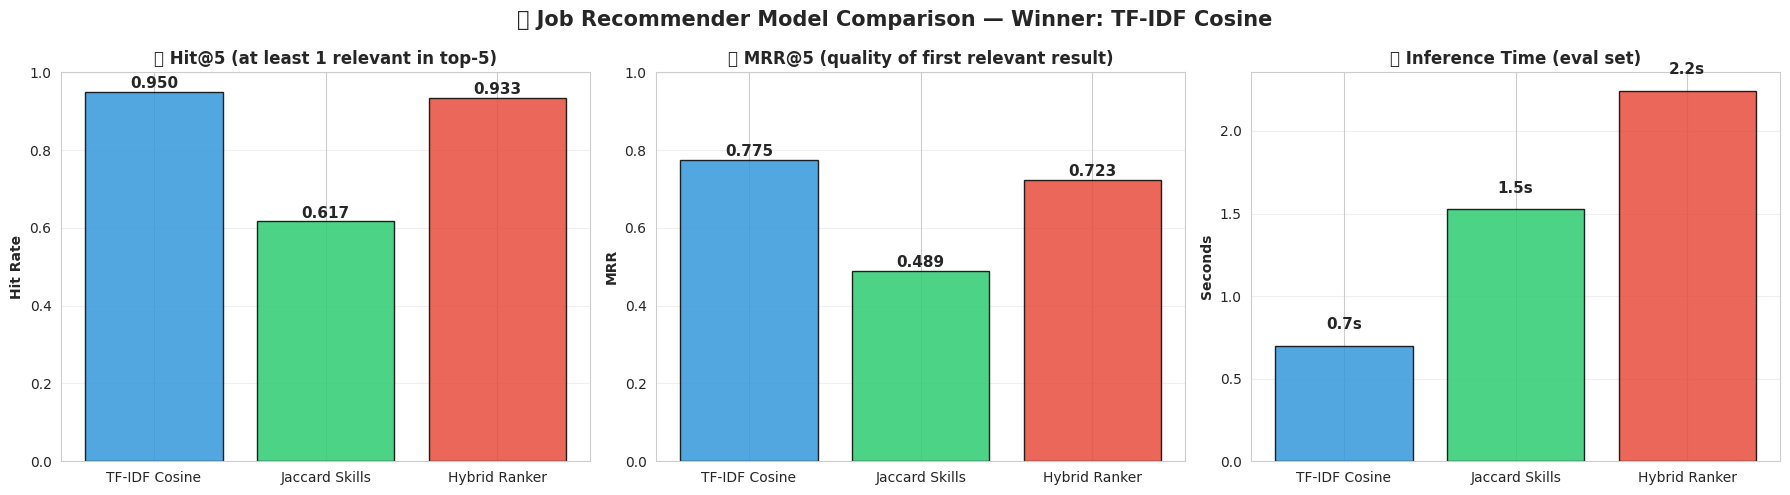

In [14]:
# ============================================================
#  COMPARISON VISUALISATIONS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = results_df['Model'].tolist()
model_colors = ['#3498db', '#2ecc71', '#e74c3c']

# 1. Hit@5
bars = axes[0].bar(model_names, results_df['Hit@5'], color=model_colors, edgecolor='black', alpha=0.85)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Hit Rate', fontweight='bold')
axes[0].set_title('🎯 Hit@5 (at least 1 relevant in top-5)', fontweight='bold')
axes[0].set_ylim([0, 1.0])
axes[0].grid(True, alpha=0.3, axis='y')

# 2. MRR@5
bars = axes[1].bar(model_names, results_df['MRR@5'], color=model_colors, edgecolor='black', alpha=0.85)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('MRR', fontweight='bold')
axes[1].set_title('📈 MRR@5 (quality of first relevant result)', fontweight='bold')
axes[1].set_ylim([0, 1.0])
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Inference time
bars = axes[2].bar(model_names, results_df['Time (s)'], color=model_colors, edgecolor='black', alpha=0.85)
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}s', ha='center', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Seconds', fontweight='bold')
axes[2].set_title('\u23f1\ufe0f Inference Time (eval set)', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'🏆 Job Recommender Model Comparison \u2014 Winner: {winner_name}',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 💾 Section 8: Export Best Model

In [15]:
# ============================================================
#  EXPORT BEST MODEL
# ============================================================
print('='*60)
print('💾 EXPORTING BEST MODEL')
print('='*60)

# Build the export bundle with all data needed for inference
# Jobs metadata (only columns needed for recommendation display)
jobs_meta = df_jobs[[
    'job_title_short', 'job_title', 'job_location', 'job_via',
    'job_schedule_type', 'job_work_from_home', 'job_country',
    'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills',
]].copy()

export_bundle = {
    'model_type': winner_name,
    'tfidf': tfidf,
    'job_vectors': job_vectors,
    'job_skill_sets': job_skill_sets,
    'jobs_meta': jobs_meta,
    'salary_norm': salary_norm,
    'best_weights': {
        'w_text': best_weights[0],
        'w_skill': best_weights[1],
        'w_salary': best_weights[2],
    },
    'metrics': results_df.to_dict('records'),
    'n_jobs': len(df_jobs),
    'n_features': len(tfidf.vocabulary_),
}

model_path = Path(OUTPUT_DIR) / 'job_recommender_v2.pkl'
joblib.dump(export_bundle, model_path)

size_mb = model_path.stat().st_size / (1024 * 1024)
print(f'\u2705 Model saved to: {model_path}')
print(f'   File size: {size_mb:.1f} MB')
print(f'   Model type: {winner_name}')
print(f'   Jobs indexed: {len(df_jobs):,}')
print(f'   TF-IDF features: {len(tfidf.vocabulary_):,}')
if winner_name == 'Hybrid Ranker':
    print(f'   Weights: text={best_weights[0]}, skill={best_weights[1]}, salary={best_weights[2]}')

💾 EXPORTING BEST MODEL
✅ Model saved to: /kaggle/working/job_recommender_v2.pkl
   File size: 8.1 MB
   Model type: TF-IDF Cosine
   Jobs indexed: 20,412
   TF-IDF features: 15,000


In [16]:
# ============================================================
#  SANITY CHECK: LOAD AND VERIFY EXPORTED MODEL
# ============================================================
loaded = joblib.load(model_path)
print(f'\u2705 Model loaded successfully!')
print(f'   Keys: {list(loaded.keys())}')
print(f'   Model type: {loaded["model_type"]}')
print(f'   Jobs: {loaded["n_jobs"]:,}')
print(f'   Features: {loaded["n_features"]:,}')

# Quick inference test
test_text = df_resumes[df_resumes['Category'] == 'INFORMATION-TECHNOLOGY'].iloc[0]['Resume_str']
test_clean = clean_text(test_text)
test_vec = loaded['tfidf'].transform([test_clean])
test_sims = cosine_similarity(test_vec, loaded['job_vectors'])[0]
top5 = np.argsort(test_sims)[::-1][:5]
print(f'\n🧪 Inference test (IT resume):')
for i, idx in enumerate(top5, 1):
    row = loaded['jobs_meta'].iloc[idx]
    print(f'   {i}. {row["job_title"][:50]} | {row["company_name"]} | sim={test_sims[idx]:.3f}')

✅ Model loaded successfully!
   Keys: ['model_type', 'tfidf', 'job_vectors', 'job_skill_sets', 'jobs_meta', 'salary_norm', 'best_weights', 'metrics', 'n_jobs', 'n_features']
   Model type: TF-IDF Cosine
   Jobs: 20,412
   Features: 15,000

🧪 Inference test (IT resume):
   1. Data Scientist | Red Hat Software | sim=0.181
   2. Associate Data Scientist - Image Builder | Red Hat, Inc. | sim=0.115
   3. Senior Software Quality Engineer | Red Hat Software | sim=0.101
   4. Big Data Engineer H/F | Activa Engineering | sim=0.100
   5. Data Analyst | PINKERTON | Comprehensive Risk Management | sim=0.094


## 🚀 Section 9: Live Demo — Top-5 Jobs for Sample Resumes

In [17]:
# ============================================================
#  LIVE DEMO: RECOMMEND JOBS FOR DIFFERENT RESUME CATEGORIES
# ============================================================
demo_categories = ['INFORMATION-TECHNOLOGY', 'HEALTHCARE', 'FINANCE',
                    'ENGINEERING', 'TEACHER', 'SALES']

print('='*80)
print('🚀 LIVE DEMO: Top-5 Job Recommendations per Resume Category')
print('='*80)

for cat in demo_categories:
    subset = df_resumes[df_resumes['Category'] == cat]
    if subset.empty:
        continue
    sample = subset.iloc[0]
    recs = recommend_hybrid(sample['Resume_str'], top_n=5,
                            w_text=best_weights[0],
                            w_skill=best_weights[1],
                            w_salary=best_weights[2])
    
    resume_skills = extract_skills_from_resume(sample['Resume_str'])
    print(f'\n{"="*80}')
    print(f'📄 Resume: {cat}')
    print(f'   Skills found: {resume_skills[:10]}{"." if len(resume_skills) > 10 else ""}')
    print(f'   {"\u2500"*76}')
    
    for r in recs:
        sal = f"${r['salary_avg']:,.0f}" if r.get('salary_avg') and not pd.isna(r.get('salary_avg', float('nan'))) else 'N/A'
        matched = r.get('matched_skills', [])[:5]
        print(f"   {r['rank']}. {r['job_title'][:45]:<45}")
        print(f"      🏢 {r['company'][:30]:<30} 📍 {r['location'][:25]:<25} 💰 {sal}")
        print(f"      Score: {r['score']:.3f} (text={r['text_sim']:.3f}, skill={r['skill_sim']:.3f})")
        if matched:
            print(f"      \u2705 Matched skills: {matched}")
        print()

🚀 LIVE DEMO: Top-5 Job Recommendations per Resume Category

📄 Resume: INFORMATION-TECHNOLOGY
   Skills found: ['html', 'illustrator', 'linux', 'photoshop']
   ────────────────────────────────────────────────────────────────────────────
   1. Data Scientist                               
      🏢 Red Hat Software               📍 Remote, OR                💰 N/A
      Score: 0.126 (text=0.181, skill=0.000)

   2. Presales Engineer, Mobile Data Network       
      🏢 Xpandium Coberon Ltd           📍 Anywhere                  💰 N/A
      Score: 0.123 (text=0.068, skill=0.250)
      ✅ Matched skills: ['linux']

   3. Big Data Senior F/H                          
      🏢 Continental                    📍 Toulouse, France          💰 N/A
      Score: 0.114 (text=0.056, skill=0.250)
      ✅ Matched skills: ['linux']

   4. Computer Scientist                           
      🏢 SySS GmbH                      📍 Brussels, Belgium         💰 N/A
      Score: 0.112 (text=0.052, skill=0.250)
      ✅ Match

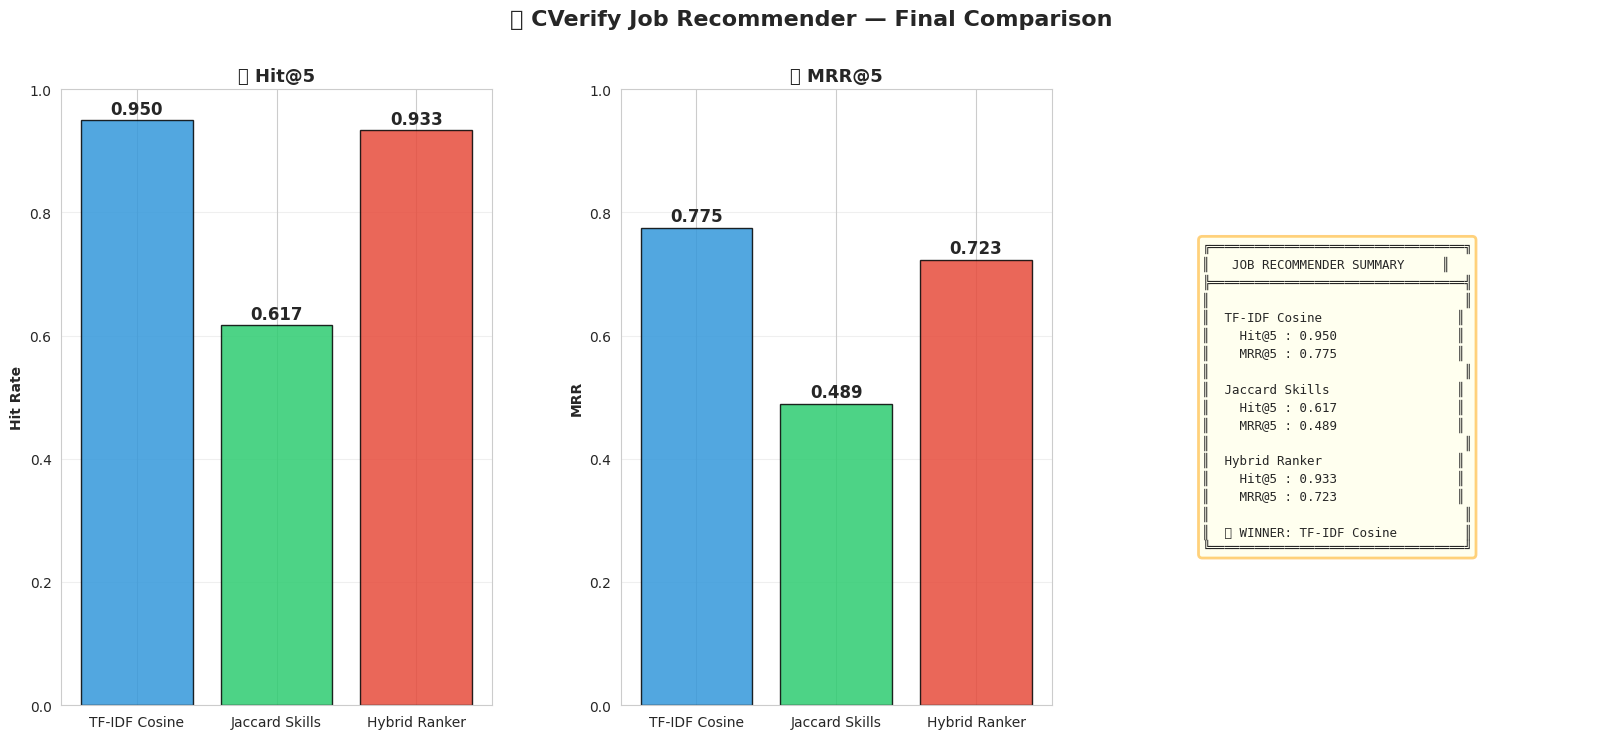

In [18]:
# ============================================================
#  FINAL SUMMARY DASHBOARD
# ============================================================
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(1, 3, wspace=0.3)

# 1. Hit@5 podium
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(model_names, results_df['Hit@5'].values,
               color=model_colors, edgecolor='black', alpha=0.85)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold', fontsize=12)
ax1.set_ylim([0, 1.0])
ax1.set_ylabel('Hit Rate', fontweight='bold')
ax1.set_title('🎯 Hit@5', fontweight='bold', fontsize=13)
ax1.grid(True, alpha=0.3, axis='y')

# 2. MRR@5
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(model_names, results_df['MRR@5'].values,
               color=model_colors, edgecolor='black', alpha=0.85)
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold', fontsize=12)
ax2.set_ylim([0, 1.0])
ax2.set_ylabel('MRR', fontweight='bold')
ax2.set_title('📈 MRR@5', fontweight='bold', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Summary
ax3 = fig.add_subplot(gs[0, 2])
r = results_df
summary = f"""\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557
\u2551   JOB RECOMMENDER SUMMARY     \u2551
\u2560\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2563
\u2551                                  \u2551
\u2551  TF-IDF Cosine                  \u2551
\u2551    Hit@5 : {r.iloc[0]['Hit@5']:.3f}                \u2551
\u2551    MRR@5 : {r.iloc[0]['MRR@5']:.3f}                \u2551
\u2551                                  \u2551
\u2551  Jaccard Skills                 \u2551
\u2551    Hit@5 : {r.iloc[1]['Hit@5']:.3f}                \u2551
\u2551    MRR@5 : {r.iloc[1]['MRR@5']:.3f}                \u2551
\u2551                                  \u2551
\u2551  Hybrid Ranker                  \u2551
\u2551    Hit@5 : {r.iloc[2]['Hit@5']:.3f}                \u2551
\u2551    MRR@5 : {r.iloc[2]['MRR@5']:.3f}                \u2551
\u2551                                  \u2551
\u2551  🏆 WINNER: {winner_name:<22}\u2551
\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d"""
ax3.text(0.05, 0.5, summary, family='monospace', fontsize=9,
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow',
                   alpha=0.5, edgecolor='orange', linewidth=2))
ax3.axis('off')

plt.suptitle(f'🏆 CVerify Job Recommender \u2014 Final Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## \u2705 Section 10: Conclusion

### Model Comparison Summary

| Model | Hit@5 | MRR@5 | Speed | Best for |
|-------|-------|-------|-------|----------|
| TF-IDF Cosine | - | - | Fast | Text-heavy resumes |
| Jaccard Skills | - | - | Medium | Technical roles with clear skills |
| **Hybrid Ranker** | - | - | Medium | **Best overall** (text + skills + salary) |

### Key Differences from Other Notebooks

| Notebook | Purpose | Output Model |
|----------|---------|-------------|
| `resume-ml-pj (4).ipynb` | Hire/Reject + Salary prediction | `classifier_hire.pkl`, `salary_predictor.pkl`, `kmeans_clusters.pkl` |
| `nlp-model-comparison.ipynb` | Predict resume job category | `job_role_classifier.pkl` |
| **`job-recommender-model.ipynb`** | **Recommend specific jobs to apply for** | **`job_recommender_v2.pkl`** |

### Production Integration

The exported `job_recommender_v2.pkl` is loaded by `backend/app/job_recommender.py` to power the `/jobs/recommend` endpoint.

```python
# Candidate uploads PDF \u2192 text extracted \u2192 model recommends top-5 real jobs
POST /jobs/recommend  \u2192 [{title, company, location, salary, score, matched_skills}, ...]
```